In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
#--------------------
#Import Data
#--------------------
DATADIR = r"D:\MIT\replication data collection"
QDATA = os.path.join(DATADIR, "data", "processed", "final", "qdata.parquet")
EXPOSURE = os.path.join(DATADIR, "raw", "extra_data", "employment-exposure.dta")
OUTDIR = os.path.join(DATADIR, "output", "covid_shock")
os.makedirs(OUTDIR, exist_ok=True)


def to_code(s):
    return pd.to_numeric(s).round().astype("Int64").astype("string")


qdata = pd.read_parquet(QDATA)
qdata["naics"] = to_code(qdata["naics"]).str[:3]

covid_exp = pd.read_stata(EXPOSURE)
covid_exp = covid_exp.query("naicslevel == 3")[["naics_code", "industry_name", "z_abnormalgrowthrate"]]
covid_exp = covid_exp.rename(columns={"naics_code": "naics", "z_abnormalgrowthrate": "covid_exp"})
covid_exp["naics"] = to_code(covid_exp["naics"])

qdata = pd.merge(qdata, covid_exp, on="naics", how="inner")
print(f"qdata after merge: {len(qdata):,} rows, {qdata['gvkey'].nunique()} firms")

qdata after merge: 3,495 rows, 150 firms


In [3]:
#--------------------
#Align Calendar Date
#--------------------
# Compustat determines a fiscal as fyear = year(datadate), if datadate>=fyear-06-01, else fyear = year(datadate)-1
# We need to change the trash hold month for Feb - due covid!
cdata = qdata.copy()
cdata["datadate"] = pd.to_datetime(cdata["datadate"])
cdata["rfyear"] = cdata["datadate"].dt.year
cdata.loc[cdata["datadate"].dt.month < 3, "rfyear"] = cdata["datadate"].dt.year - 1

# create quarter
cdata["datacqtr"] = cdata["datadate"].dt.to_period("Q")

# before 2019: one observation per year, labelled Q4
early = cdata["rfyear"] < 2019
cdata.loc[early, "datacqtr"] = pd.PeriodIndex(cdata.loc[early, "rfyear"].astype(str) + "Q4", freq="Q")

mapping = {
    "2019Q1": "2018Q4",
    "2019Q2": "2019Q4",
    "2019Q3": "2019Q4",
    "2021Q1": "2020Q4",
    "2021Q2": "2021Q4",
    "2021Q3": "2021Q4",
    "2022Q1": "2021Q4",
}
for old, new in mapping.items():
    cdata.loc[cdata["datacqtr"] == pd.Period(old, "Q"), "datacqtr"] = pd.Period(new, "Q")

# keep the latest observation in each firm-quarter
cdata = cdata.sort_values(["gvkey", "datadate"])
cdata = cdata.drop_duplicates(["gvkey", "datacqtr"], keep="last")
cdata = cdata[cdata["rfyear"] >= 2015]

# drop non-complete data
cdata["nobs"] = cdata.groupby("gvkey")["gvkey"].transform("size")
cdata_all = cdata.copy()
cdata = cdata[cdata["nobs"] == 10].copy()
print(f"Balanced panel: {cdata['gvkey'].nunique()} firms, {len(cdata)} rows")

Balanced panel: 119 firms, 1190 rows


In [4]:
q0 = pd.read_parquet(QDATA)
q0["naics3"] = to_code(q0["naics"]).str[:3]

no_match = set(q0["gvkey"]) - set(qdata["gvkey"])
print("firms in qdata:", q0["gvkey"].nunique())
print("firms lost in exposure merge:", len(no_match))
print(q0[q0["gvkey"].isin(no_match)].groupby("gvkey")[["conm", "naics3"]].first())

lost = cdata_all[cdata_all["nobs"] != 10]
print("firms lost in balancing:", lost["gvkey"].nunique())
print(lost.groupby("gvkey").agg(conm=("conm", "first"), nobs=("nobs", "first")).sort_values("nobs", ascending=False).head(10))

firms in qdata: 156
firms lost in exposure merge: 6
                                conm naics3
gvkey                                      
002710          CONSTELLATION BRANDS    312
003505      MOLSON COORS BEVERAGE CO    312
007906               NIKE INC  -CL B    316
008543              ALTRIA GROUP INC    312
012756  COCA-COLA EUROPACIFIC PARTNE    312
179621   PHILIP MORRIS INTERNATIONAL    312
firms lost in balancing: 29
                     conm  nobs
gvkey                          
002184    BEST BUY CO INC     9
003336  DXC TECHNOLOGY CO     9
003813        TARGET CORP     9
005680     HOME DEPOT INC     9
004611         MACY'S INC     9
007171      MCKESSON CORP     9
006502          KROGER CO     9
006829     LOWE'S COS INC     9
011259        WALMART INC     9
178083   VMWARE INC -CL A     9


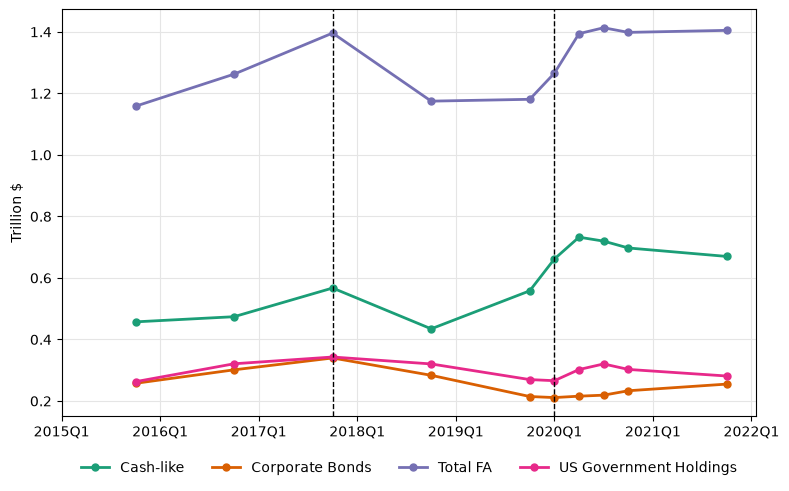

,cash_agg,corp_bond,total_fa,gov_bond
datacqtr,,,,
2015Q4,0.457288,0.257511,1.158250,0.262855
2016Q4,0.474058,0.301373,1.262593,0.321031
2017Q4,0.567291,0.339885,1.396092,0.343022
2018Q4,0.434606,0.283545,1.174773,0.320491
2019Q4,0.558219,0.214593,1.180783,0.269625
2020Q1,0.661598,0.211166,1.265585,0.266036
2020Q2,0.732577,0.215710,1.394142,0.302291
2020Q3,0.719738,0.218989,1.413377,0.320521
2020Q4,0.697483,0.233341,1.398312,0.302657


In [5]:
#--------------------
#Figure 5 - Aggregate Portfolio Dynamics: 2015–2021
#--------------------
sdata = cdata[["gvkey", "datacqtr", "conm", "total_fa", "cash_agg", "corp_debt_agg", "us_gov_debt_agg"]]
sdata = sdata.rename(columns={"corp_debt_agg": "corp_bond", "us_gov_debt_agg": "gov_bond"})

series = ["cash_agg", "corp_bond", "total_fa", "gov_bond"]
agg_data = sdata.groupby("datacqtr")[series].agg(lambda s: s.sum(skipna=False)).sort_index()
agg_data = agg_data / 1_000_000

labels = ["Cash-like", "Corporate Bonds", "Total FA", "US Government Holdings"]
colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]
x = agg_data.index.year + (agg_data.index.quarter - 1) / 4

fig, ax = plt.subplots(figsize=(8, 5))
for col, label, color in zip(series, labels, colors):
    ax.plot(x, agg_data[col], color=color, linewidth=2, marker="o", markersize=5, label=label)
for q in ["2020Q1", "2017Q4"]:
    p = pd.Period(q, "Q")
    ax.axvline(p.year + (p.quarter - 1) / 4, color="black", linestyle="--", linewidth=1)
ticks = np.arange(np.floor(x.min()), np.ceil(x.max()) + 0.01, 1)
ax.set_xticks(ticks, [f"{int(t)}Q1" for t in ticks])
ax.set_ylabel("Trillion $")
ax.grid(color="#e5e5e5", linewidth=0.8)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "tax_reform_covid_agg.png"), dpi=200)
plt.show()

agg_data

In [6]:
#--------------------
#Table 3 - Effects of COVID: Difference-in-Difference Regressions
#--------------------
cdata["post"] = (cdata["datacqtr"] >= pd.Period("2020Q1", "Q")).astype(int)
window = (cdata["datacqtr"] >= pd.Period("2018Q4", "Q")) & (cdata["datacqtr"] <= pd.Period("2020Q4", "Q"))

reg_data = pd.DataFrame({
    "gvkey": cdata["gvkey"],
    "datacqtr": cdata["datacqtr"].astype(str),
    "conm": cdata["conm"],
    "total_fa_at": cdata["total_fa"] / cdata["at"],
    "cash_like_at": cdata["cash_agg"] / cdata["at"],
    "mkt_sec_at": cdata["no_cash"] / cdata["at"],
    "gov_bond_at": cdata["us_gov_debt_agg"] / cdata["at"],
    "corp_at": cdata["corp_debt_agg"] / cdata["at"],
    "post": cdata["post"],
    "covid_exp": -cdata["covid_exp"],
})[window]

outcomes = {
    "total_fa_at": "total FA/AT",
    "cash_like_at": "cash-like/AT",
    "mkt_sec_at": "mkt securities/AT",
    "gov_bond_at": "US gov bonds/AT",
    "corp_at": "corp bonds/AT",
}


def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""


models = {}
rows = {}
for y, label in outcomes.items():
    m = smf.ols(f"{y} ~ post:covid_exp + C(datacqtr) + C(gvkey)", data=reg_data).fit()
    models[label] = m
    b, se, p = m.params["post:covid_exp"], m.bse["post:covid_exp"], m.pvalues["post:covid_exp"]
    rows[label] = {
        "post:covid_exposure": f"{b:.3f}{stars(p)}",
        "": f"({se:.3f})",
        "Observations": int(m.nobs),
        "R2": f"{m.rsquared:.3f}",
        "Adjusted R2": f"{m.rsquared_adj:.3f}",
    }

table3 = pd.DataFrame(rows)
table3.to_csv(os.path.join(OUTDIR, "reg_covid_DID.csv"))
table3

,total FA/AT,cash-like/AT,mkt securities/AT,US gov bonds/AT,corp bonds/AT
post:covid_exposure,0.018***,0.016***,0.002,0.002*,-0.001
,(0.005),(0.004),(0.003),(0.001),(0.002)
Observations,714,714,714,714,714
R2,0.918,0.763,0.947,0.979,0.859
Adjusted R2,0.901,0.713,0.936,0.974,0.829


In [7]:
# Leave-one-out check for the corporate bond regression (Table 3, column 5):
# re-estimate the coefficient dropping one firm at a time and list the firms
# whose removal moves it the most, to see whether a single firm drives the sign
rows = []
for f in reg_data["gvkey"].unique():
    m = smf.ols("corp_at ~ post:covid_exp + C(datacqtr) + C(gvkey)", data=reg_data[reg_data["gvkey"] != f]).fit()
    rows.append((f, m.params["post:covid_exp"]))

loo = pd.DataFrame(rows, columns=["gvkey", "coef_without"]).sort_values("coef_without")
loo = loo.merge(cdata.groupby("gvkey")["conm"].first().reset_index(), on="gvkey")
print(loo.head(5))
print(loo.tail(5))

    gvkey  coef_without                       conm
0  020779     -0.001216          CISCO SYSTEMS INC
1  001690     -0.000841                  APPLE INC
2  161844     -0.000825       LAS VEGAS SANDS CORP
3  028930     -0.000825          MARRIOTT INTL INC
4  014418     -0.000825  MGM RESORTS INTERNATIONAL
      gvkey  coef_without                          conm
114  114524     -0.000413                      EBAY INC
115  010795     -0.000402  UNITED AIRLINES HOLDINGS INC
116  008549     -0.000353                CONOCOPHILLIPS
117  024800      0.000397                  QUALCOMM INC
118  119314      0.001919          BOOKING HOLDINGS INC


In [8]:
# For firms dropped from the balanced panel, list which of the 10 time points they miss,
# together with their fiscal year-end month, to tell structural losses
# (non-December fiscal years, mergers, late listings) from data problems
all_points = sorted(cdata["datacqtr"].astype(str).unique())
lost = cdata_all[cdata_all["nobs"] != 10]
missing = lost.groupby("gvkey").agg(
    conm=("conm", "first"),
    fy_end_month=("datadate", lambda d: d.dt.month.mode()[0]),
    have=("datacqtr", lambda q: set(q.astype(str))),
)
missing["missing"] = missing["have"].apply(lambda h: [p for p in all_points if p not in h])
print(missing[["conm", "fy_end_month", "missing"]].to_string())

                                conm  fy_end_month                                   missing
gvkey                                                                                       
002184               BEST BUY CO INC             1                                  [2019Q4]
002490  BURLINGTON NORTHERN SANTA FE            12  [2020Q1, 2020Q2, 2020Q3, 2020Q4, 2021Q4]
003336             DXC TECHNOLOGY CO             3                                  [2019Q4]
003362            CONAGRA BRANDS INC             5          [2020Q1, 2020Q3, 2020Q4, 2021Q4]
003813                   TARGET CORP             1                                  [2019Q4]
004598                    FEDEX CORP             5          [2020Q1, 2020Q3, 2020Q4, 2021Q4]
004611                    MACY'S INC             1                                  [2019Q4]
005071             GENERAL MILLS INC             5          [2020Q1, 2020Q3, 2020Q4, 2021Q4]
005680                HOME DEPOT INC             1                    